In [1]:
!pip install names
import pandas as pd
import numpy as np
import os
import random
import names
import matplotlib.pyplot as plt
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.1/789.1 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for names: filename=names-0.3.0-py3-none-any.whl size=803681 sha256=3a4009597db3e00975ebbe5d862a9fec1a6901a1ea3b3ef67909e6181c1e690b
  Stored in directory: /root/.cache/pip/wheels/8d/db/fc/50ec19a89a8dcbbd158a4aae44123cb525cda1f07dae287197
Successfully built names


In [ ]:
df = pd.read_excel('Dmart.xlsx')
df.shape

(6428, 18)

In [ ]:
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales (shipping price included)', 'Profit',
       'Quantity'],
      dtype='object')

In [ ]:
df.rename(columns = {'Sales (shipping price included)' : 'Sales'}, inplace = True)

In [ ]:
df.head(2)

,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales,Profit,Quantity
0,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,1205.000000,866.294118,870.294118,334.705882,-1.0,869.294118,4.0,1
1,2015-01-02,Moderate,Named Day,Yingcheng,Hubei,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,320.823529,323.823529,204.411765,1.0,324.823529,3.0,1


In [ ]:
df.nunique()

Order Date                       371
Order Priority                     4
Ship Type                          4
City                             294
State                             67
Country                            9
Region                             3
Segment                            3
Super Category                    31
Category                         137
Price                           3156
Operational/ Production Cost    2929
Selling Price                   2293
Discount                         870
Shipping Cost                   1362
Sales                           2893
Profit                          1410
Quantity                           5
dtype: int64

In [ ]:
reg_df = df.groupby('Region', as_index = False)['Sales'].sum().round(2)
reg_df

,Region,Sales
0,Central Asia,2632621.12
1,North Asia,2698224.13
2,Southeast Asia,230874.94


# Pie Chart

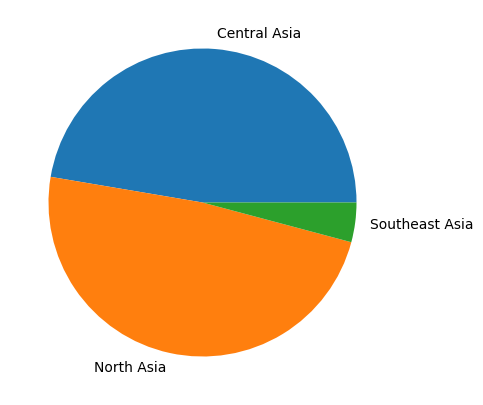

In [ ]:
plt.figure(figsize = (10, 5))
plt.pie(reg_df['Sales'], labels = reg_df['Region']);

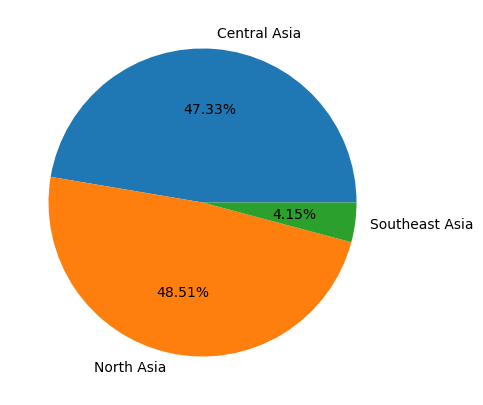

In [ ]:
plt.figure(figsize = (10, 5))
plt.pie(reg_df['Sales'], labels = reg_df['Region'], autopct = "%1.2f%%");

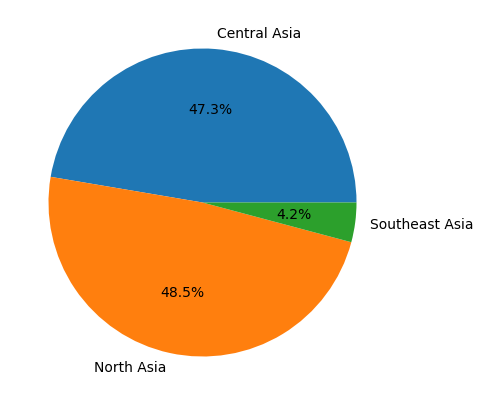

In [ ]:
plt.figure(figsize = (10, 5))
plt.pie(reg_df['Sales'], labels = reg_df['Region'], autopct = "%1.1f%%");

# Violin Plot

In [ ]:
df['Sales'].describe()

count     6428.000000
mean       865.233384
std       2639.154865
min          4.529412
25%         80.333333
50%        140.441176
75%        391.028056
max      42854.863900
Name: Sales, dtype: float64

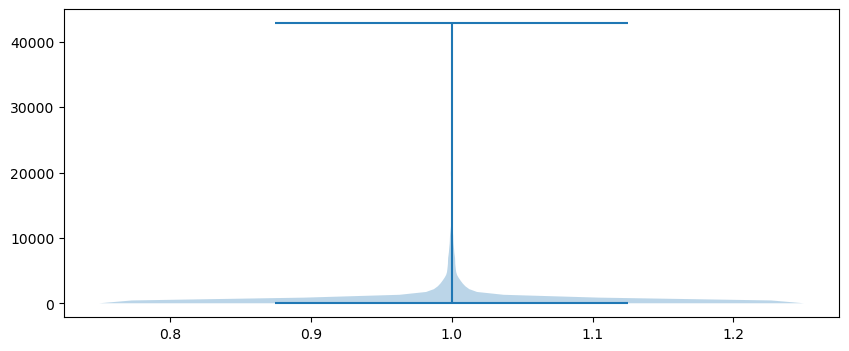

In [ ]:
plt.figure(figsize = (10, 4))
plt.violinplot(df['Sales']);

In [ ]:
df['Sales'].shape

(6428,)

In [ ]:
len(df[df['Sales'] > 800])

1087

In [ ]:
len(df[df['Sales'] > 10000])

98

In [ ]:
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales', 'Profit', 'Quantity'],
      dtype='object')

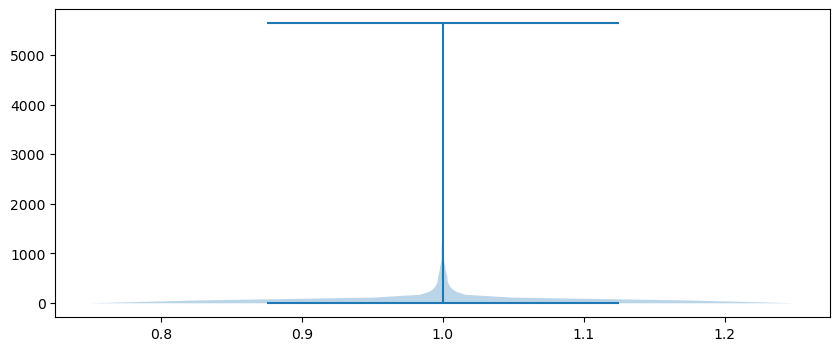

In [ ]:
plt.figure(figsize = (10, 4))
plt.violinplot(df['Shipping Cost']);

# Distribution Plot

In [ ]:
x = np.arange(0, 10, 0.2)
y = np.sin(x)

In [ ]:
print(x)

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6 6.8 7.
 7.2 7.4 7.6 7.8 8.  8.2 8.4 8.6 8.8 9.  9.2 9.4 9.6 9.8]


In [ ]:
print(y)

[ 0.          0.19866933  0.38941834  0.56464247  0.71735609  0.84147098
  0.93203909  0.98544973  0.9995736   0.97384763  0.90929743  0.8084964
  0.67546318  0.51550137  0.33498815  0.14112001 -0.05837414 -0.2555411
 -0.44252044 -0.61185789 -0.7568025  -0.87157577 -0.95160207 -0.993691
 -0.99616461 -0.95892427 -0.88345466 -0.77276449 -0.63126664 -0.46460218
 -0.2794155  -0.0830894   0.1165492   0.31154136  0.49411335  0.6569866
  0.79366786  0.8987081   0.96791967  0.99854335  0.98935825  0.94073056
  0.85459891  0.7343971   0.58491719  0.41211849  0.22288991  0.02477543
 -0.17432678 -0.36647913]


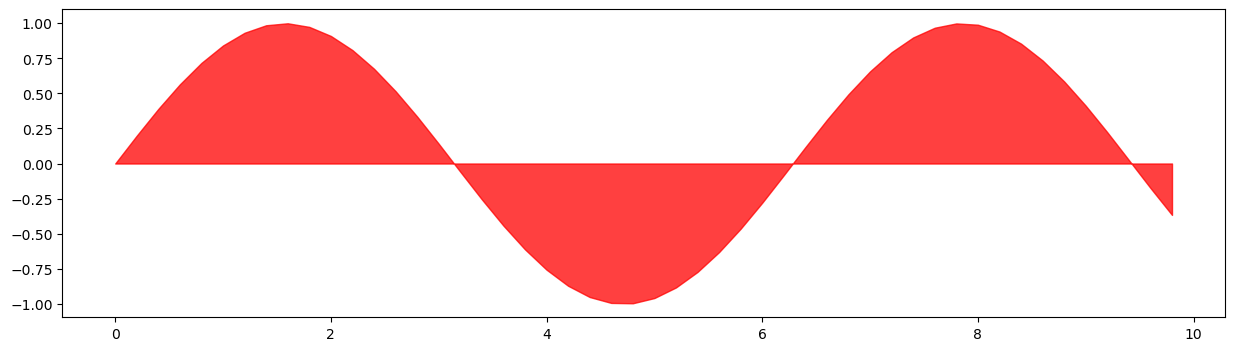

In [ ]:
plt.figure(figsize = (5, 2))
plt.fill_between(x, y, alpha = 0.75 , color = 'r');

# Seaborn

In [ ]:
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales', 'Profit', 'Quantity'],
      dtype='object')

In [ ]:
df.dtypes

Order Date                      datetime64[ns]
Order Priority                          object
Ship Type                               object
City                                    object
State                                   object
Country                                 object
Region                                  object
Segment                                 object
Super Category                          object
Category                                object
Price                                  float64
Operational/ Production Cost           float64
Selling Price                          float64
Discount                               float64
Shipping Cost                          float64
Sales                                  float64
Profit                                 float64
Quantity                                 int64
dtype: object

In [ ]:
df.head()

,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales,Profit,Quantity
0,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,1205.000000,866.294118,870.294118,334.705882,-1.0,869.294118,4.0,1
1,2015-01-02,Moderate,Named Day,Yingcheng,Hubei,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,320.823529,323.823529,204.411765,1.0,324.823529,3.0,1
2,2015-01-02,Moderate,Named Day,Chongqing,Chongqing,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,215.686275,142.098039,145.098039,70.588235,0.0,145.098039,3.0,1
3,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,318.823529,323.823529,204.411765,0.0,323.823529,5.0,1
4,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,137.450980,71.372549,76.372549,61.078431,1.0,77.372549,5.0,1


In [ ]:
pd.DatetimeIndex(df['Order Date']).month_name()

Index(['January', 'January', 'January', 'January', 'January', 'January',
       'January', 'January', 'January', 'January',
       ...
       'December', 'December', 'December', 'December', 'December', 'December',
       'December', 'December', 'December', 'December'],
      dtype='object', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).month

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).quarter

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).year

Index([2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015,
       ...
       2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).day

Index([ 2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).day_name()

Index(['Friday', 'Friday', 'Friday', 'Friday', 'Friday', 'Friday', 'Friday',
       'Friday', 'Friday', 'Friday',
       ...
       'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday',
       'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday'],
      dtype='object', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).dayofweek

Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       ...
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).isocalendar().week

Order Date
2015-01-02     1
2015-01-02     1
2015-01-02     1
2015-01-02     1
2015-01-02     1
              ..
2018-12-12    50
2018-12-12    50
2018-12-12    50
2018-12-12    50
2018-12-12    50
Name: week, Length: 6428, dtype: UInt32

In [ ]:
df['Month'] = pd.DatetimeIndex(df['Order Date']).month_name()
df['Month_no'] = pd.DatetimeIndex(df['Order Date']).month
df['Year'] = pd.DatetimeIndex(df['Order Date']).year

In [ ]:
test = df.groupby(['Month', 'Year'], as_index = False)['Sales'].sum()
test['Year'] = test['Year'].astype('str')
test['Month'] + '-' + test['Year'].str[-2:]

0         April-15
1         April-16
2         April-17
3         April-18
4        August-15
5        August-16
6        August-17
7        August-18
8      December-15
9      December-16
10     December-17
11     December-18
12     February-15
13     February-16
14     February-17
15     February-18
16      January-15
17      January-16
18      January-17
19      January-18
20         July-15
21         July-16
22         July-17
23         July-18
24         June-15
25         June-16
26         June-17
27         June-18
28        March-15
29        March-16
30        March-17
31        March-18
32          May-15
33          May-16
34          May-17
35          May-18
36     November-15
37     November-16
38     November-17
39     November-18
40      October-15
41      October-16
42      October-17
43      October-18
44    September-15
45    September-16
46    September-17
47    September-18
dtype: object

# Monthly Sales Trend

In [ ]:
df['Month'] = pd.DatetimeIndex(df['Order Date']).month_name()
df['Month_no'] = pd.DatetimeIndex(df['Order Date']).month

In [ ]:
trend = df.groupby(['Month', 'Month_no'], as_index = False)['Sales'].sum().round(2)

In [ ]:
trend = trend.sort_values(by = 'Month_no').reset_index(drop = True)
trend['Month'] = trend['Month'].str[:3]

In [ ]:
trend

,Month,Month_no,Sales
0,Jan,1,541875.59
1,Feb,2,562972.54
2,Mar,3,373412.25
3,Apr,4,531443.16
4,May,5,323981.94
5,Jun,6,514447.06
6,Jul,7,508245.15
7,Aug,8,398355.13
8,Sep,9,369082.92
9,Oct,10,323740.87


## Line Chart

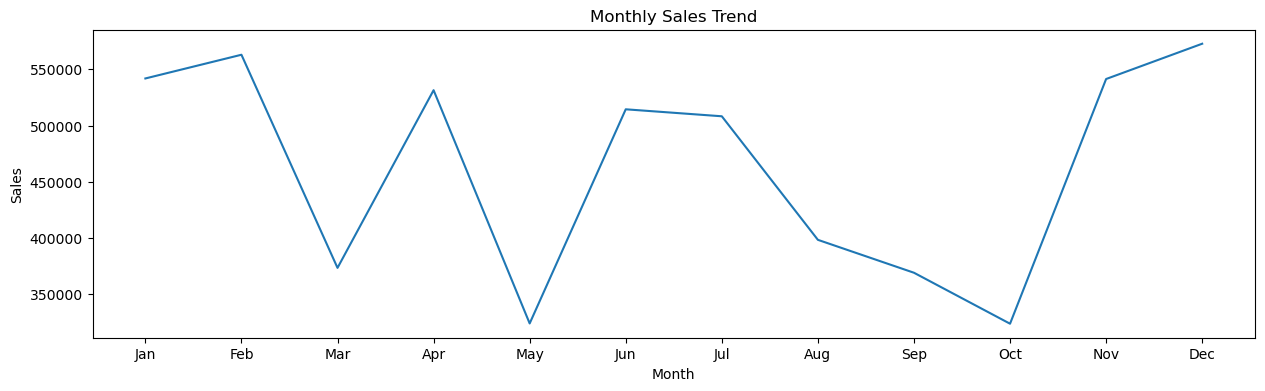

In [ ]:
plt.figure(figsize = (15, 4))
plt.title("Monthly Sales Trend")
sns.lineplot(x = 'Month', y = 'Sales', data = trend);

++# Colors

‘Accent’, ‘Accent_r’, ‘Blues’, ‘Blues_r’, ‘BrBG’, ‘BrBG_r’, ‘BuGn’, ‘BuGn_r’, ‘BuPu’, ‘BuPu_r’, ‘CMRmap’, ‘CMRmap_r’, ‘Dark2’, ‘Dark2_r’, ‘GnBu’, ‘GnBu_r’,  ‘Greens’, ‘Greens_r’, ‘Greys’, ‘Greys_r’, ‘OrRd’, ‘OrRd_r’, ‘Oranges’, ‘Oranges_r’,  ‘PRGn’, ‘PRGn_r’, ‘Paired’, ‘Paired_r’, ‘Pastel1’, ‘Pastel1_r’, ‘Pastel2’,  ‘Pastel2_r’, ‘PiYG’, ‘PiYG_r’, ‘PuBu’, ‘PuBuGn’, ‘PuBuGn_r’, ‘PuBu_r’, ‘PuOr’, ‘PuOr_r’, ‘PuRd’, ‘PuRd_r’, ‘Purples’, ‘Purples_r’, ‘RdBu’, ‘RdBu_r’, ‘RdGy’, ‘RdGy_r’, ‘RdPu’, ‘RdPu_r’, ‘RdYlBu’, ‘RdYlBu_r’, ‘RdYlGn’, ‘RdYlGn_r’, ‘Reds’, ‘Reds_r’, ‘Set1’, ‘Set1_r’, ‘Set2’, ‘Set2_r’, ‘Set3’, ‘Set3_r’, ‘Spectral’, ‘Spectral_r’, ‘Wistia’, ‘Wistia_r’, ‘YlGn’, ‘YlGnBu’, ‘YlGnBu_r’, ‘YlGn_r’, ‘YlOrBr’, ‘YlOrBr_r’, ‘YlOrRd’, ‘YlOrRd_r’, ‘afmhot’, ‘afmhot_r’, ‘autumn’, ‘autumn_r’, ‘binary’, ‘binary_r’,  ‘bone’, ‘bone_r’, ‘brg’, ‘brg_r’, ‘bwr’, ‘bwr_r’, ‘cividis’, ‘cividis_r’, ‘cool’, ‘cool_r’,  ‘coolwarm’, ‘coolwarm_r’, ‘copper’, ‘copper_r’, ‘cubehelix’, ‘cubehelix_r’, ‘flag’, ‘flag_r’,  ‘gist_earth’, ‘gist_earth_r’, ‘gist_gray’, ‘gist_gray_r’, ‘gist_heat’, ‘gist_heat_r’, ‘gist_ncar’,  ‘gist_ncar_r’, ‘gist_rainbow’, ‘gist_rainbow_r’, ‘gist_stern’, ‘gist_stern_r’, ‘gist_yarg’,  ‘gist_yarg_r’, ‘gnuplot’, ‘gnuplot2’, ‘gnuplot2_r’, ‘gnuplot_r’, ‘gray’, ‘gray_r’, ‘hot’, ‘hot_r’,  ‘hsv’, ‘hsv_r’, ‘icefire’, ‘icefire_r’, ‘inferno’, ‘inferno_r’, ‘jet’, ‘jet_r’, ‘magma’, ‘magma_r’,  ‘mako’, ‘mako_r’, ‘nipy_spectral’, ‘nipy_spectral_r’, ‘ocean’, ‘ocean_r’, ‘pink’, ‘pink_r’,  ‘plasma’, ‘plasma_r’, ‘prism’, ‘prism_r’, ‘rainbow’, ‘rainbow_r’, ‘rocket’, ‘rocket_r’,  ‘seismic’, ‘seismic_r’, ‘spring’, ‘spring_r’, ‘summer’, ‘summer_r’, ‘tab10’, ‘tab10_r’,’tab20′, ‘tab20_r’, ‘tab20b’, ‘tab20b_r’, ‘tab20c’, ‘tab20c_r’, ‘terrain’, ‘terrain_r’, ‘turbo’,  ‘turbo_r’, ‘twilight’, ‘twilight_r’, ‘twilight_shifted’, ‘twilight_shifted_r’, ‘viridis’,  ‘viridis_r’, ‘vlag’, ‘vlag_r’, ‘winter’, ‘winter_r’

# Bar Chart

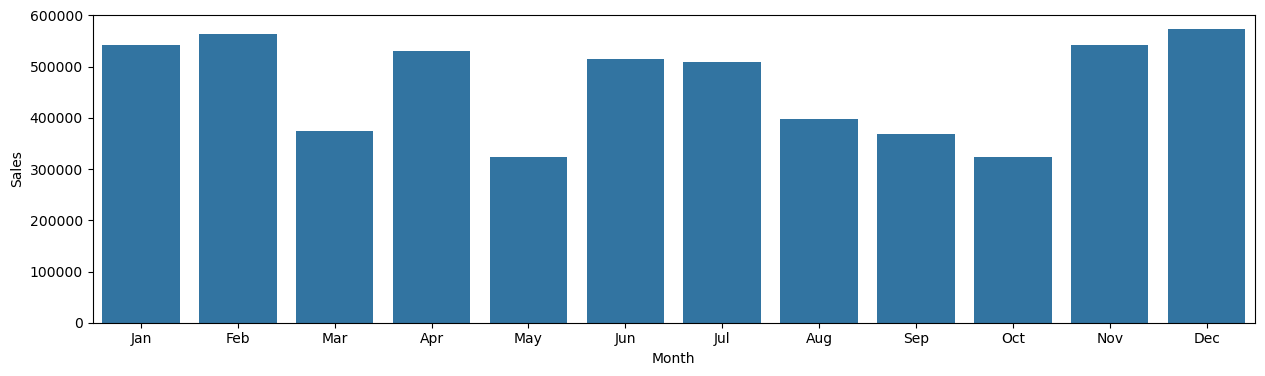

In [ ]:
plt.figure(figsize = (15, 4))
sns.barplot(x = 'Month', y = 'Sales', data = trend);

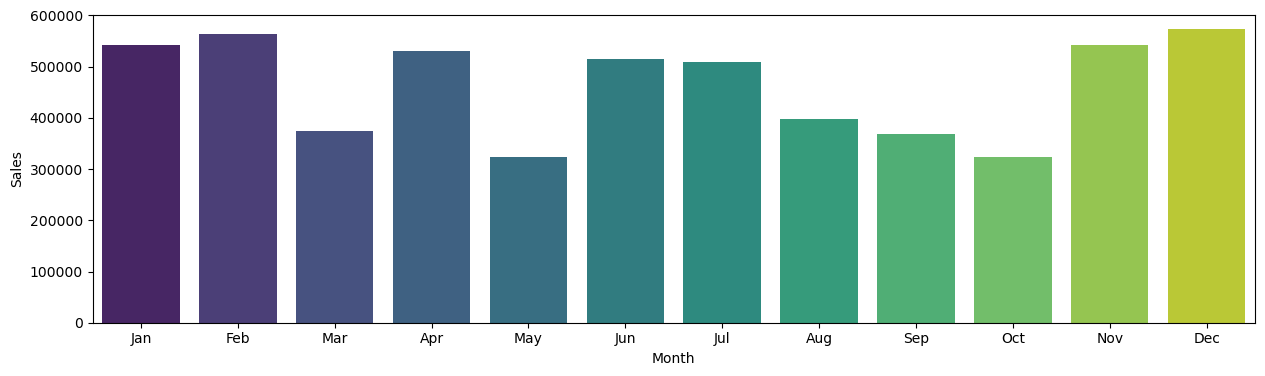

In [ ]:
plt.figure(figsize = (15, 4))
sns.barplot(x = 'Month', y = 'Sales', data = trend, hue = 'Month', palette = 'viridis');

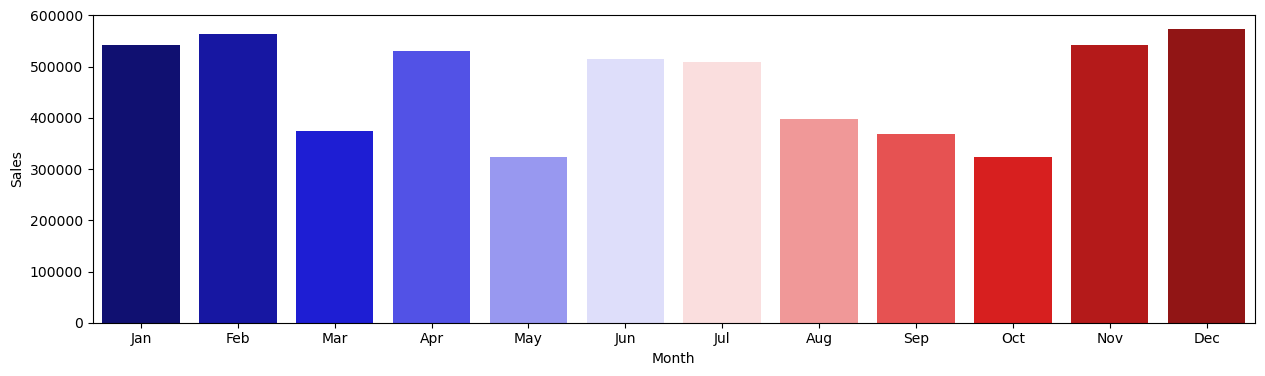

In [ ]:
plt.figure(figsize = (15, 4))
sns.barplot(x = 'Month', y = 'Sales', data = trend, hue = 'Month', palette = 'seismic');

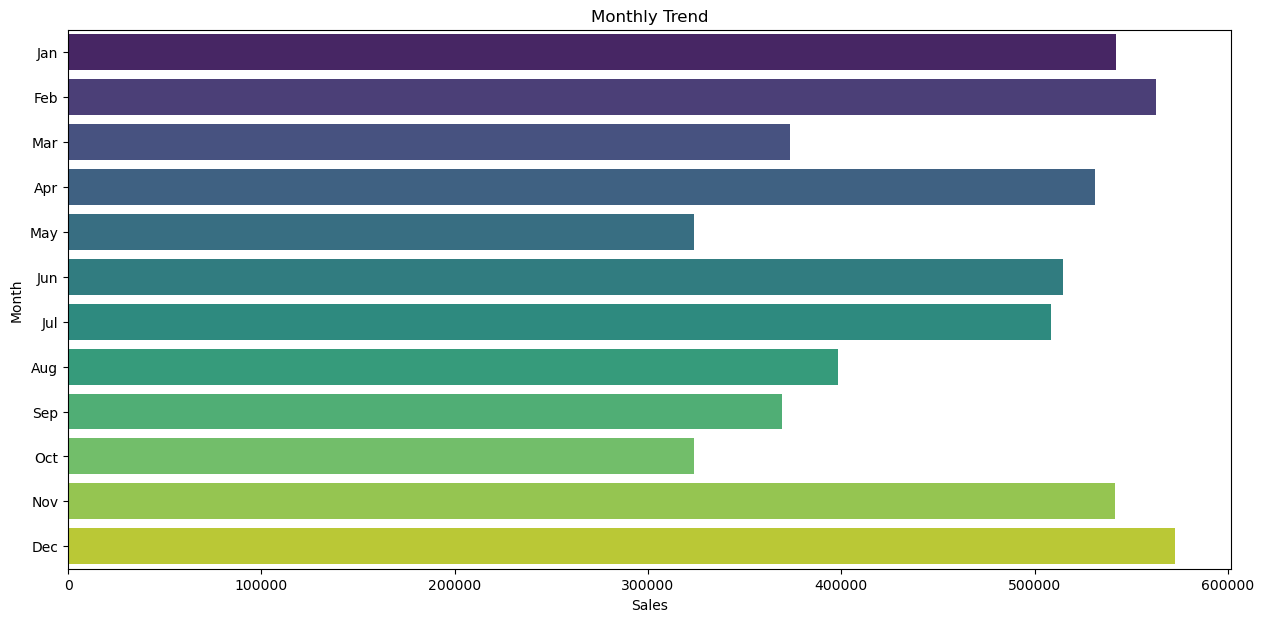

In [ ]:
plt.figure(figsize = (15, 7))
plt.title('Monthly Trend')
sns.barplot(y = 'Month', x = 'Sales', data = trend, hue = 'Month', palette = 'viridis');

# Histogram

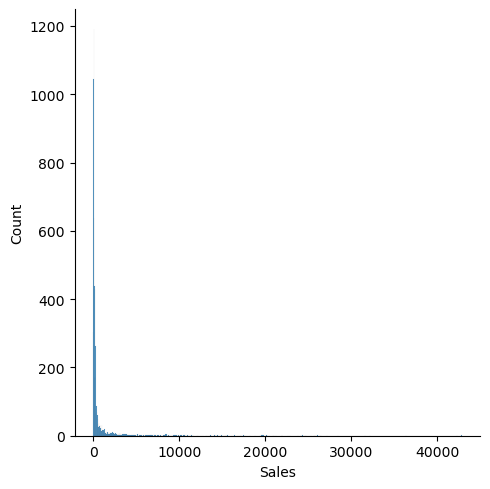

In [ ]:
sns.displot(df['Sales']);

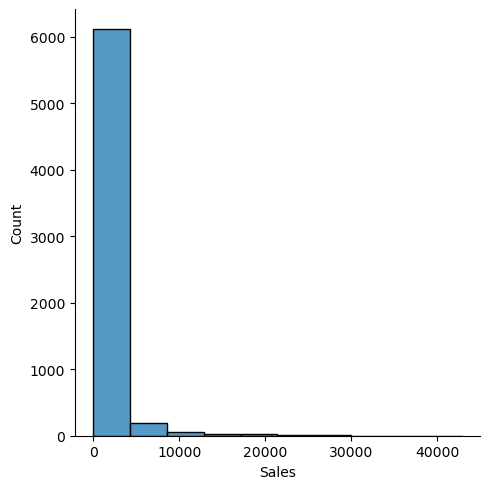

In [ ]:
sns.displot(df['Sales'], bins = 10);

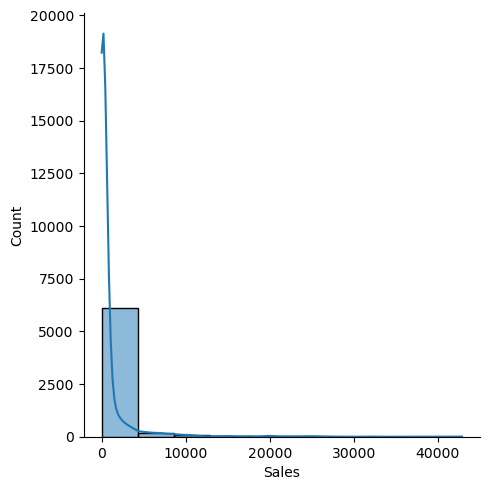

In [ ]:
sns.displot(df['Sales'], bins = 10, kde = True);

In [ ]:
dummy = pd.read_excel("Superstore.xlsx")
dummy.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Ratio
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.160000
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.300000
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,114.6200,2,0.00,6.8714,0.059949
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.400000
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.112500


In [ ]:
dummy.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Profit Ratio'],
      dtype='object')

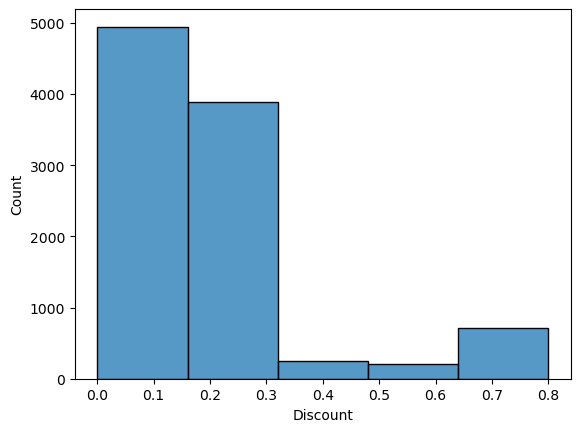

In [ ]:
sns.histplot(dummy['Discount'], bins = 5);

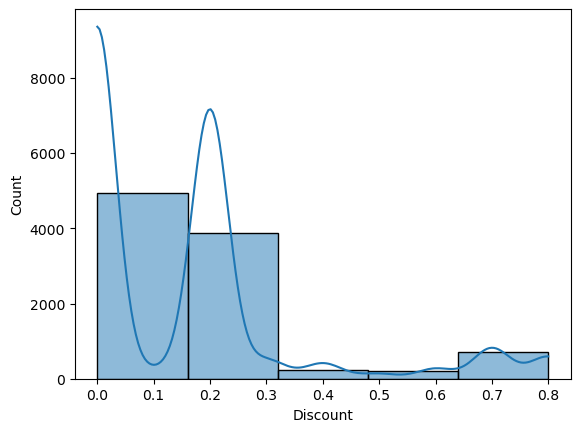

In [ ]:
sns.histplot(dummy['Discount'], bins = 5, kde = True);

# Scatter Plot

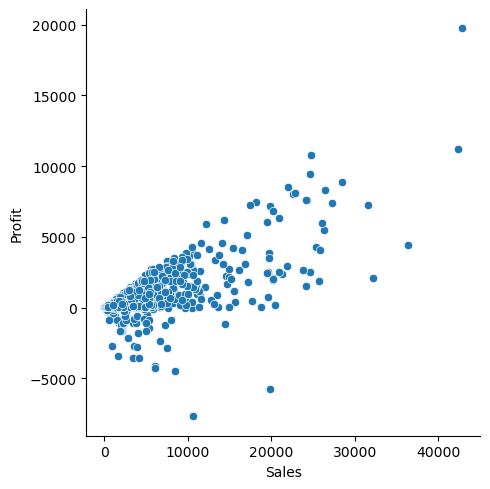

In [ ]:
sns.relplot(x = 'Sales', y = 'Profit', data = df);

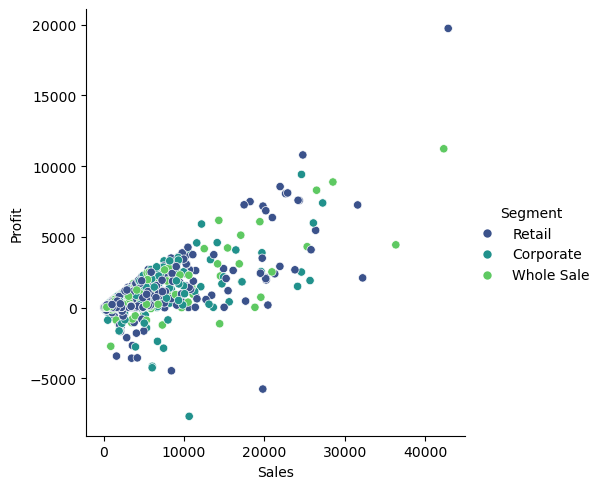

In [ ]:
sns.relplot(x = 'Sales', y = 'Profit', data = df, hue = 'Segment', palette = 'viridis');

# Bubble Plot

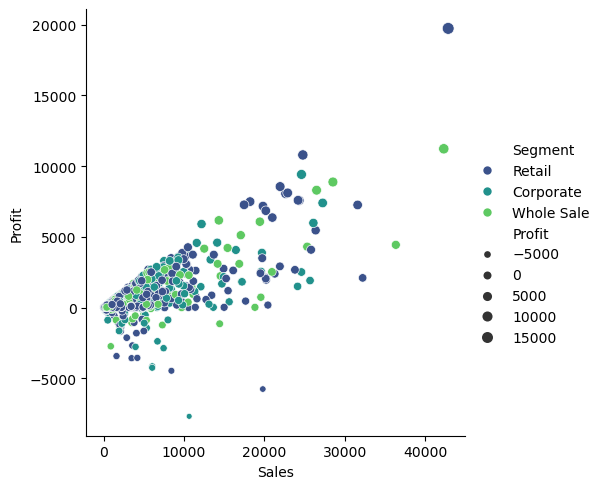

In [ ]:
sns.relplot(x = 'Sales', y = 'Profit', data = df, hue = 'Segment', palette = 'viridis', size = 'Profit');

# Boxplot

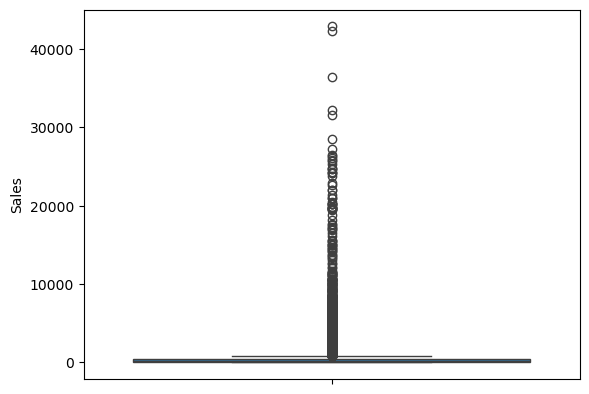

In [ ]:
sns.boxplot(df['Sales']);

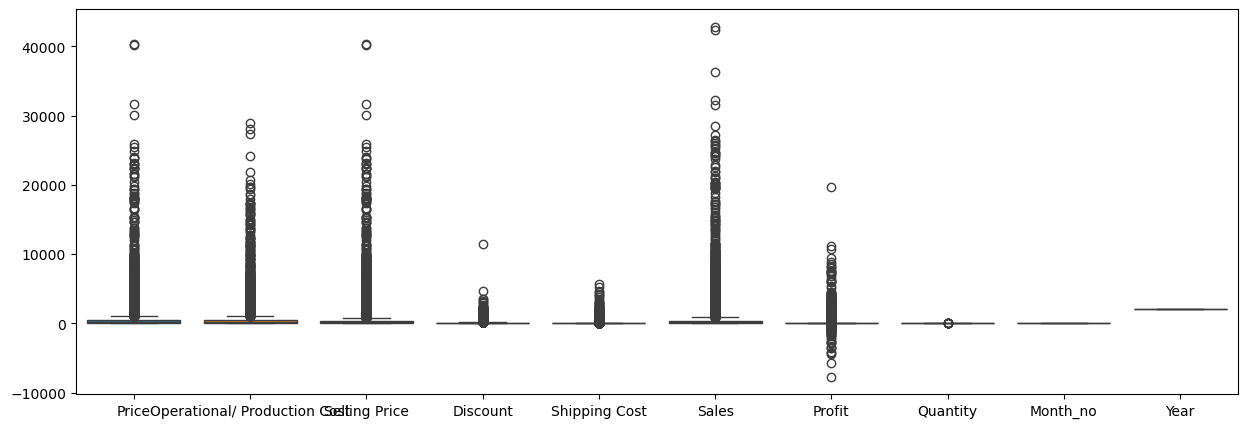

In [ ]:
plt.figure(figsize = (15, 5))
sns.boxplot(df);

# Heatmap

In [ ]:
df.corr()

ValueError: could not convert string to float: 'Moderate'

In [ ]:
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales', 'Profit', 'Quantity', 'Month', 'Month_no',
       'Year'],
      dtype='object')

In [ ]:
df1 = df.iloc[:, 10:16]
df1.head()

,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales
0,1205.000000,866.294118,870.294118,334.705882,-1.0,869.294118
1,528.235294,320.823529,323.823529,204.411765,1.0,324.823529
2,215.686275,142.098039,145.098039,70.588235,0.0,145.098039
3,528.235294,318.823529,323.823529,204.411765,0.0,323.823529
4,137.450980,71.372549,76.372549,61.078431,1.0,77.372549


In [ ]:
df1.corr()

,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales
Price,1.000000,0.968439,0.994740,0.137775,0.817612,0.991675
Operational/ Production Cost,0.968439,1.000000,0.970469,0.055950,0.804798,0.968471
Selling Price,0.994740,0.970469,1.000000,0.035596,0.832765,0.998110
Discount,0.137775,0.055950,0.035596,1.000000,-0.075453,0.023970
Shipping Cost,0.817612,0.804798,0.832765,-0.075453,1.000000,0.865208
Sales,0.991675,0.968471,0.998110,0.023970,0.865208,1.000000


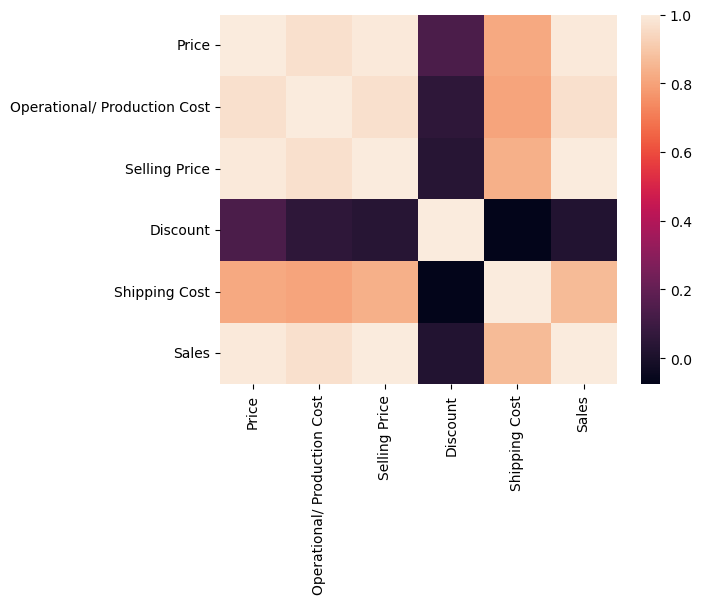

In [ ]:
sns.heatmap(df1.corr());

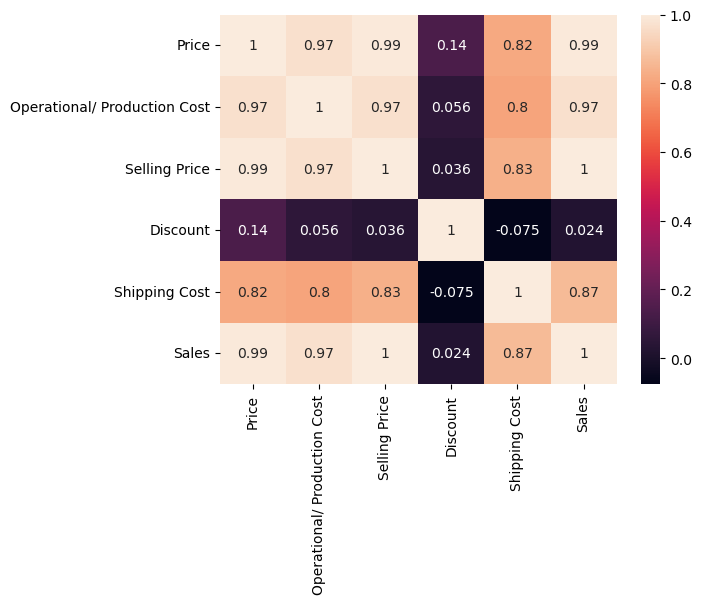

In [ ]:
sns.heatmap(df1.corr(), annot = True);

# Catplot

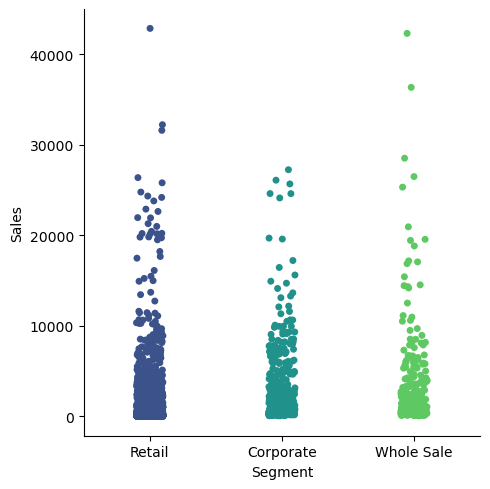

In [ ]:
sns.catplot(x = 'Segment', y = 'Sales', data = df, hue = 'Segment', palette = 'viridis');

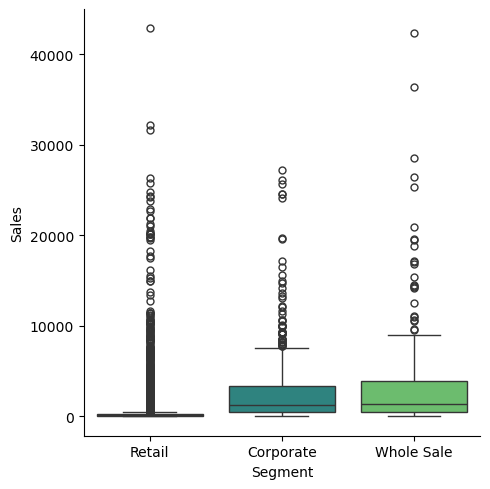

In [ ]:
sns.catplot(x = 'Segment', y = 'Sales', data = df, hue = 'Segment', palette = 'viridis', kind = 'box');

# Distribution Plot

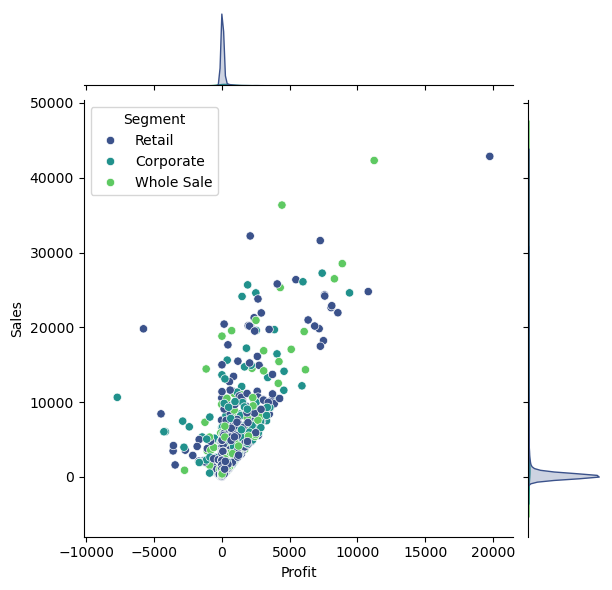

In [ ]:
sns.jointplot(x = 'Profit', y = 'Sales', data = df, hue = 'Segment', palette = 'viridis');

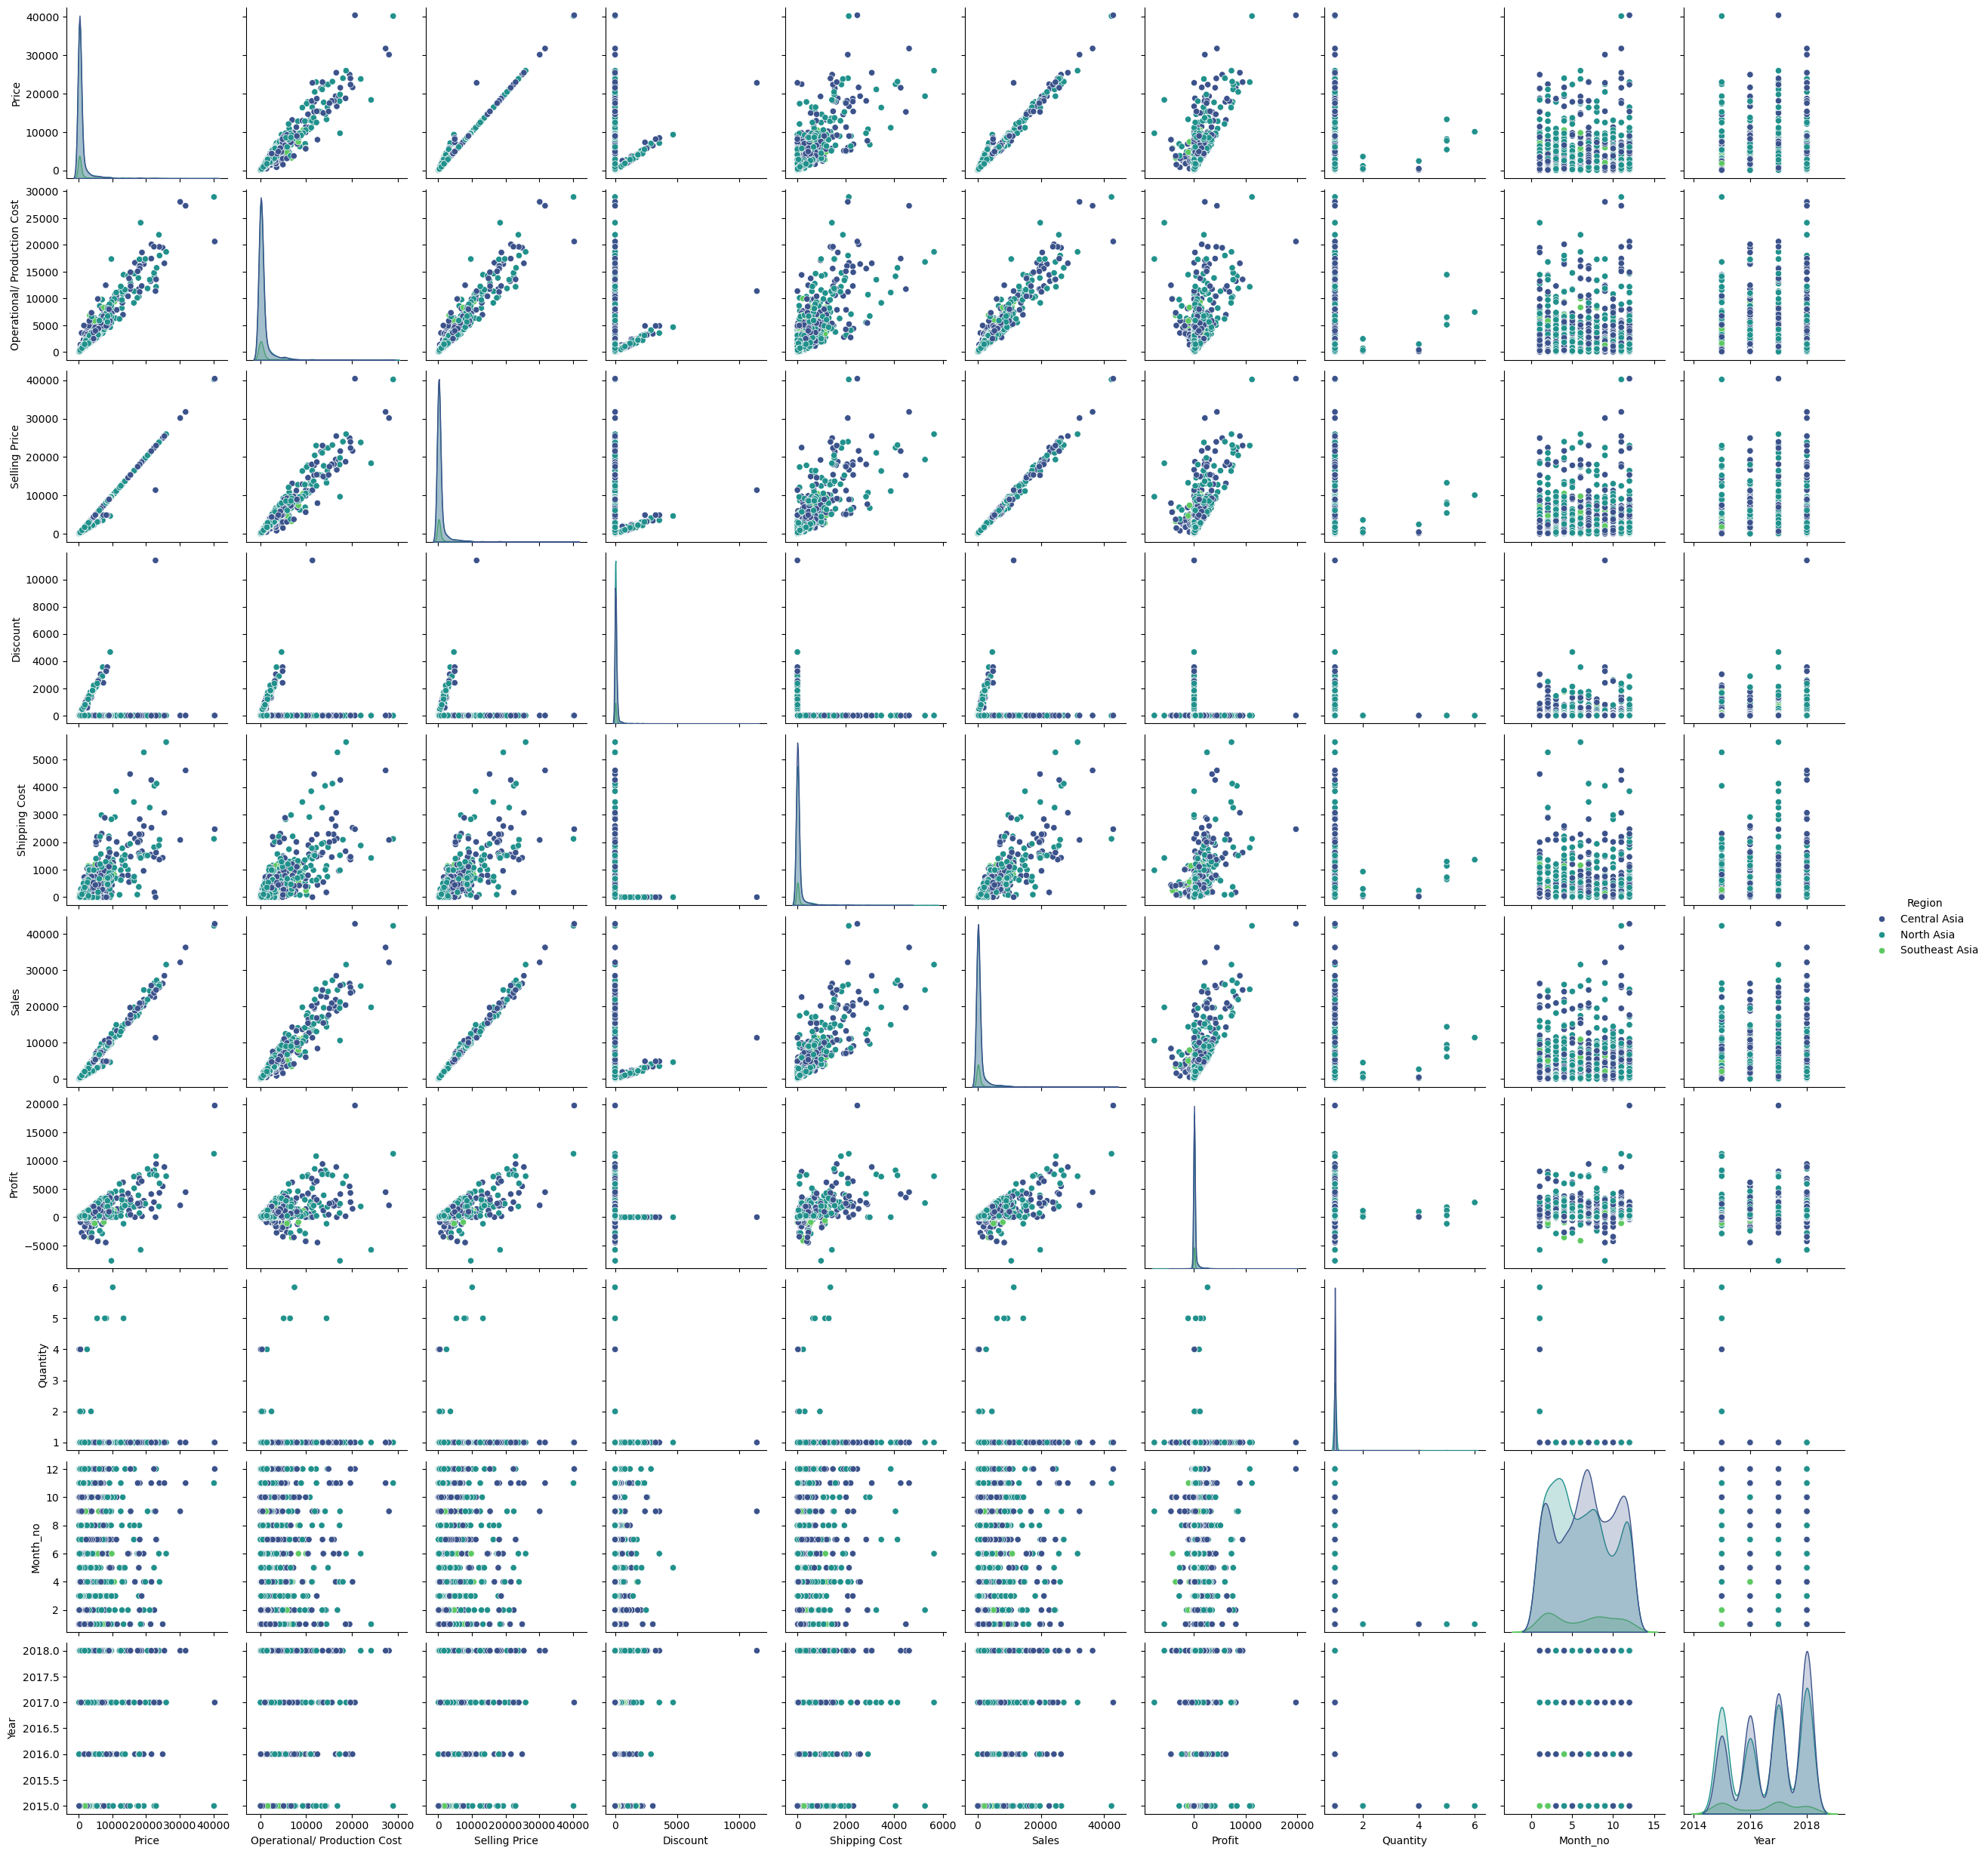

In [ ]:
sns.pairplot(df, hue = 'Region', palette = 'viridis');